In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('titanic_data_updated.csv')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,no,third,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,yes,first,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,yes,third,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,yes,first,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,no,third,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,no,second,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,yes,first,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,no,third,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,yes,first,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [3]:
df.drop(['PassengerId','Name', 'Ticket'], axis=1,inplace=True)

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,no,third,male,22.0,1,0,7.2500,NaN,S
1,yes,first,female,38.0,1,0,71.2833,C85,C
2,yes,third,female,26.0,0,0,7.9250,NaN,S
3,yes,first,female,35.0,1,0,53.1000,C123,S
4,no,third,male,35.0,0,0,8.0500,NaN,S


In [4]:
df.isnull().sum()

# df.drop(['Cabin'],axis=1, inplace=True)
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,no,third,male,22.0,1,0,7.2500,NaN,S
1,yes,first,female,38.0,1,0,71.2833,C85,C
2,yes,third,female,26.0,0,0,7.9250,NaN,S
3,yes,first,female,35.0,1,0,53.1000,C123,S
4,no,third,male,35.0,0,0,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...
886,no,second,male,27.0,0,0,13.0000,NaN,S
887,yes,first,female,19.0,0,0,30.0000,B42,S
888,no,third,female,NaN,1,2,23.4500,NaN,S
889,yes,first,male,26.0,0,0,30.0000,C148,C


In [32]:
df.drop(['Cabin'],axis=1, inplace=True )

In [33]:
X = df.drop(['Survived'],axis=1 )
X

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,third,male,22.0,1,0,7.2500,S
1,first,female,38.0,1,0,71.2833,C
2,third,female,26.0,0,0,7.9250,S
3,first,female,35.0,1,0,53.1000,S
4,third,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...
886,second,male,27.0,0,0,13.0000,S
887,first,female,19.0,0,0,30.0000,S
888,third,female,NaN,1,2,23.4500,S
889,first,male,26.0,0,0,30.0000,C


In [34]:
y = df['Survived']

y

0       no
1      yes
2      yes
3      yes
4       no
      ... 
886     no
887    yes
888     no
889    yes
890     no
Name: Survived, Length: 891, dtype: str

In [7]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [35]:
from sklearn.model_selection import train_test_split

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2,random_state=42)

In [37]:
X_train
display(y_train)

331     no
733     no
382     no
704     no
813     no
      ... 
106    yes
270     no
860     no
435    yes
102     no
Name: Survived, Length: 712, dtype: str

In [38]:
X_test
display(y_test)

709    yes
439     no
840     no
720    yes
39     yes
      ... 
433     no
773     no
25     yes
84     yes
10     yes
Name: Survived, Length: 179, dtype: str

# Imputing missing value

# Imputing numerical features -> Mean, Median

with pandas

In [39]:
X_train.isnull().sum()

Pclass        0
Sex           0
Age         140
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

In [40]:
X_test.isnull().sum()

Pclass       0
Sex          0
Age         37
SibSp        0
Parch        0
Fare         0
Embarked     0
dtype: int64

In [58]:
# Mean impute
age_mean = X_train['Age'].mean()

X_train['age_mean_imputor'] = X_train['Age'].fillna(age_mean)

X_test['age_mean_imputor'] = X_train['Age'].fillna(age_mean)


In [59]:
# Median Impute

age_median = X_train['Age'].mean()

X_train['age_median_imputor'] = X_train['Age'].fillna(age_median)

X_test['age_median_imputor'] = X_train['Age'].fillna(age_median)

X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,age_mean_imputor,age_median_imputor
331,first,male,45.500000,0,0,28.5000,S,45.500000,45.500000
733,second,male,23.000000,0,0,13.0000,S,23.000000,23.000000
382,third,male,32.000000,0,0,7.9250,S,32.000000,32.000000
704,third,male,26.000000,1,0,7.8542,S,26.000000,26.000000
813,third,female,6.000000,4,2,31.2750,S,6.000000,6.000000
...,...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,S,21.000000,21.000000
270,first,male,29.498846,0,0,31.0000,S,29.498846,29.498846
860,third,male,41.000000,2,0,14.1083,S,41.000000,41.000000
435,first,female,14.000000,1,2,120.0000,S,14.000000,14.000000


<Axes: xlabel='age_mean_imputor', ylabel='Density'>

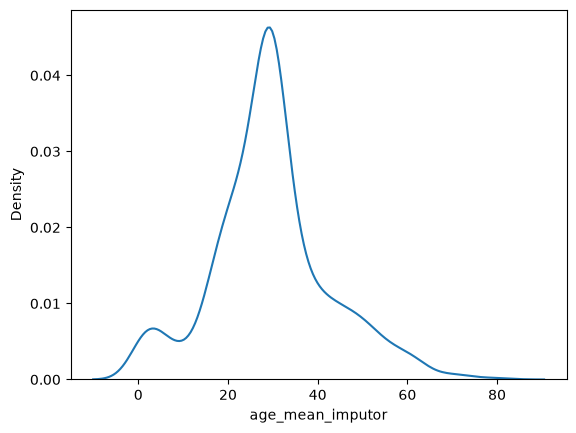

In [46]:
sns.kdeplot(data=X_train, x='age_mean_imputor')

<Axes: xlabel='age_median_imputor', ylabel='Density'>

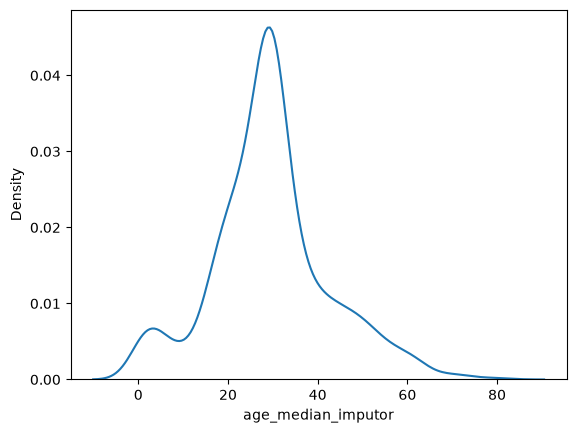

In [50]:
sns.kdeplot(data=X_train, x='age_median_imputor')

# Simple Imputor

In [52]:
from sklearn.impute import SimpleImputer


In [53]:
age_imputer = SimpleImputer(missing_values=np.nan, strategy='mean')

age_imputer.fit(X_train[['Age']])

X_train['Age'] = age_imputer.transform(X_train[['Age']])

In [62]:
X_train.isnull().sum()
X_train.drop(['age_mean_imputor','age_median_imputor'],axis=1,inplace=True)

X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
331,first,male,45.500000,0,0,28.5000,S
733,second,male,23.000000,0,0,13.0000,S
382,third,male,32.000000,0,0,7.9250,S
704,third,male,26.000000,1,0,7.8542,S
813,third,female,6.000000,4,2,31.2750,S
...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,S
270,first,male,29.498846,0,0,31.0000,S
860,third,male,41.000000,2,0,14.1083,S
435,first,female,14.000000,1,2,120.0000,S


In [63]:
X_test['Age'] = age_imputer.transform(X_test[['Age']])

X_test.isnull().sum()

Pclass                  0
Sex                     0
Age                     0
SibSp                   0
Parch                   0
Fare                    0
Embarked                0
age_mean_imputor      179
age_median_imputor    179
dtype: int64

In [65]:
X_test.drop(['age_mean_imputor','age_median_imputor'],axis=1,inplace=True)

X_test

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
709,third,male,29.498846,1,1,15.2458,C
439,second,male,31.000000,0,0,10.5000,S
840,third,male,20.000000,0,0,7.9250,S
720,second,female,6.000000,0,1,33.0000,S
39,third,female,14.000000,1,0,11.2417,C
...,...,...,...,...,...,...,...
433,third,male,17.000000,0,0,7.1250,S
773,third,male,29.498846,0,0,7.2250,C
25,third,female,38.000000,1,5,31.3875,S
84,second,female,17.000000,0,0,10.5000,S
